# Chapter 39 — The Transducer Idea: Engineering Strain into Measurement
### *Modern Strain Gage Technology* — Companion Notebook

**A transducer turns a physical quantity you care about — force, pressure, torque, acceleration — into an electrical signal, on purpose.**

Companion notebook to Chapter 39 — The Transducer Idea: Engineering Strain into Measurement.

A transducer is a structure that converts a physical quantity into an electrical signal through a *deliberate* and controlled mechanical deformation. The key word is *deliberate*: the geometry is designed so that strain gages bonded at specific locations produce an output that is linearly proportional to the input quantity and insensitive to everything else.

The *cantilever beam load cell* is the archetypal example. A beam of known geometry and material, loaded transversely at its tip, develops a bending moment that is maximum at the root. Four strain gages bonded there — two on the tension face, two on the compression face — form a full Wheatstone bridge that is sensitive only to the tip force and immune to axial loads, thermal expansion, and common-mode electrical noise. The output is a voltage that, once calibrated, directly reports the applied force. This notebook calculates the sensitivity and full-scale output of a representative design.

**This notebook demonstrates:**
1. Cantilever beam load cell: bending stress, surface strain, and full-bridge output voltage vs. applied force (0–1500 N), and the sensitivity-versus-range trade-off set by beam height.

In [1]:
# !pip install numpy matplotlib
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

%matplotlib inline
plt.rcParams.update({'figure.dpi': 120, 'font.size': 11, 'axes.titlesize': 12})

# Figures are written next to the chapter source so the book can \includegraphics them.
OUT_DIR = Path("../src/media/ch39")
OUT_DIR.mkdir(parents=True, exist_ok=True)

---
## 1 — Cantilever Beam Load Cell: Sensitivity vs. Range

The cantilever beam geometry produces bending stress σ = 6FL / (bh²) at the root cross-section, where L is the moment arm, b is the width, and h is the height. This stress is linearly proportional to the applied force F. The surface strain at the root is ε = σ/E, and the output of a full Wheatstone bridge with four active gages in bending (two in tension, two in compression) is V_out = V_ex · GF · ε.

Both sensitivity and stress scale as 1/h², which sets up the central trade-off of spring-element design. The plot compares three beam heights (8, 10, 12 mm) for the same L, b, and material: the thinnest beam produces the most output per newton but reaches its allowable working stress (marked dots) at the lowest force. All three reach the same output ceiling at the allowable stress — they simply get there at different loads. Choosing h is therefore choosing where to sit on the sensitivity-versus-range curve. The example uses steel (E = 200 GPa) and an allowable stress of 300 MPa.

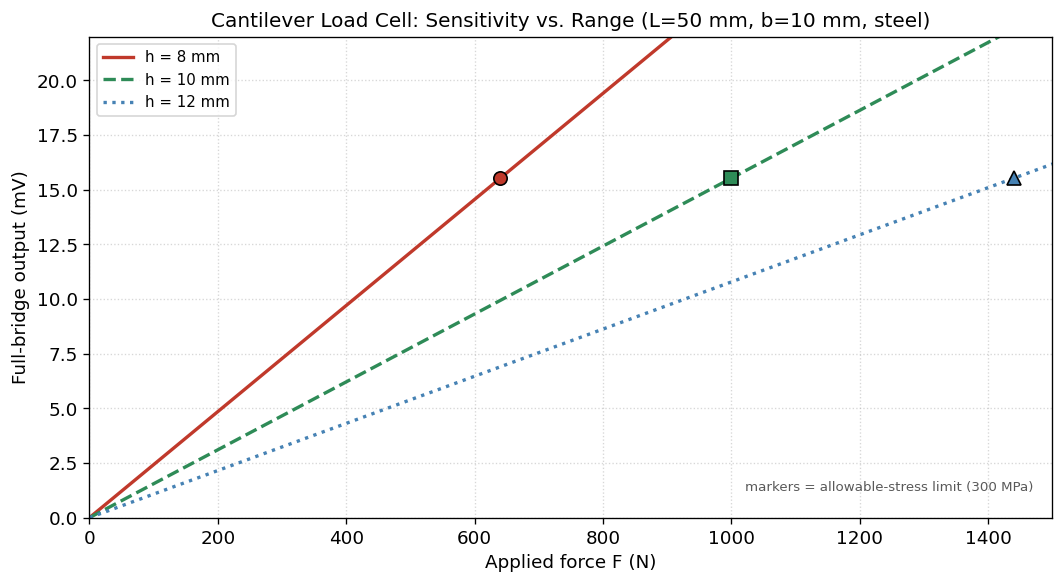

h=8 mm: sensitivity=0.0243 mV/N, F_allow=640 N
h=10 mm: sensitivity=0.0155 mV/N, F_allow=1000 N
h=12 mm: sensitivity=0.0108 mV/N, F_allow=1440 N


In [2]:
# Cantilever beam load cell: the sensitivity-vs-range trade-off across beam heights.
# The three governing relations, each wrapped in a small documented function below:
#   sigma = 6 F L / (b h^2)   (root bending stress)
#   eps   = sigma / E         (surface strain)
#   Vout  = Vex * GF * eps     (full four-arm bridge output)

MV_PER_V = 1000.0  # millivolts per volt


def bending_stress(F, L, b, h):
    """Root bending stress of a transversely tip-loaded rectangular cantilever, in Pa.

    sigma = M / S = (F L) / (b h^2 / 6) = 6 F L / (b h^2).
    """
    return 6.0 * F * L / (b * h**2)


def surface_strain(sigma, E):
    """Surface strain from stress via Hooke's law (uniaxial), dimensionless: eps = sigma / E."""
    return sigma / E


def full_bridge_output(eps, Vex, GF):
    """Output of a full four-arm bending bridge (2 tension, 2 compression arms), in volts.

    All four arms see |eps|, so the arm mismatches add: Vout = Vex * GF * eps.
    """
    return Vex * GF * eps


def force_at_stress(sigma, L, b, h):
    """Applied tip force that produces a given root bending stress, in N (inverse of bending_stress)."""
    return sigma * b * h**2 / (6.0 * L)


# --- Design constants (SI units) ---
E = 200e9            # elastic modulus of steel (Pa)
GF = 2.07            # gage factor (constantan foil)
Vex = 5.0            # bridge excitation (V)
L = 0.050            # moment arm, load point to gaged root (m)
b = 0.010            # beam width (m)
sigma_allow = 300e6  # allowable working stress (Pa)
heights = [0.008, 0.010, 0.012]        # beam heights (m)
colors = ['#c0392b', 'seagreen', 'steelblue']
# a second, non-color cue for the black-and-white softcover edition
styles = ['-', '--', ':']
markers = ['o', 's', '^']

F = np.linspace(0, 1500, 400)          # applied force sweep (N)
fig, ax = plt.subplots(figsize=(9, 5))
for h, c, ls, mk in zip(heights, colors, styles, markers):
    sigma = bending_stress(F, L, b, h)
    Vout = full_bridge_output(surface_strain(sigma, E), Vex, GF) * MV_PER_V  # mV
    F_allow = force_at_stress(sigma_allow, L, b, h)                          # force at allowable stress
    V_allow = full_bridge_output(surface_strain(sigma_allow, E), Vex, GF) * MV_PER_V  # output at allowable stress
    ax.plot(F, Vout, color=c, lw=2, ls=ls, label=f'h = {h*1000:.0f} mm')
    ax.plot(F_allow, V_allow, mk, color=c, mec='k', ms=8, zorder=5)

ax.text(0.98, 0.05, 'markers = allowable-stress limit (300 MPa)',
        transform=ax.transAxes, ha='right', va='bottom', fontsize=8, color='0.35')
ax.set_xlabel('Applied force F (N)')
ax.set_ylabel('Full-bridge output (mV)')
ax.set_title('Cantilever Load Cell: Sensitivity vs. Range (L=50 mm, b=10 mm, steel)')
ax.legend(fontsize=9)
ax.grid(True, linestyle=':', alpha=0.5)
ax.set_xlim(0, 1500); ax.set_ylim(0, 22)
plt.tight_layout()
plt.savefig(OUT_DIR / 'fig39_nb1_load_cell_response.png', bbox_inches='tight', dpi=300)
plt.show()

for h in heights:
    sens = full_bridge_output(surface_strain(bending_stress(1.0, L, b, h), E), Vex, GF) * MV_PER_V  # mV per N
    F_allow = force_at_stress(sigma_allow, L, b, h)
    print(f'h={h*1000:.0f} mm: sensitivity={sens:.4f} mV/N, F_allow={F_allow:.0f} N')

---
## Where to take this next

The single figure above captures only the first decision in spring-element design — where to sit on the sensitivity-versus-range curve. A few concrete extensions turn this notebook into a working design tool:

1. **Add an overload and safety-factor view.** Right now the dots mark the allowable working stress. Overlay the yield stress and plot the ratio of yield force to rated force, so you can see the overload margin each beam height buys. Try rating each beam at, say, 60% of `sigma_allow` and read off the resulting full-scale output.
2. **Swap the material (Chapter 41 preview).** Re-run with aluminum (`E = 69e9`) and beryllium copper, holding geometry fixed. Because output scales as `1/E` for a given stress but strain does not, you will see how modulus reshapes the sensitivity-range trade-off — the exact question Chapter 41 takes up in spring-element material selection.
3. **Compare spring-element configurations (Chapter 40 preview).** Add a shear-web and a column element alongside the bending beam and plot output-per-newton against stiffness for all three. This previews the bending / shear-web / column comparison that opens the next chapter, where the spring element becomes the central design decision.
